In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\amrit\Downloads\archive (1)\Churn_Modelling.csv")
print(df)

      RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMemb

In [2]:
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


Accuracy : 0.7925

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1607
           1       0.48      0.54      0.51       393

    accuracy                           0.79      2000
   macro avg       0.68      0.70      0.69      2000
weighted avg       0.80      0.79      0.80      2000


Confusion Matrix:

[[1372  235]
 [ 180  213]]

Feature Importance:

             Feature  Importance
3                Age    0.224268
9    EstimatedSalary    0.153078
0        CreditScore    0.145561
5            Balance    0.144951
6      NumOfProducts    0.120560
4             Tenure    0.071089
8     IsActiveMember    0.068530
1          Geography    0.037411
2             Gender    0.017007
7          HasCrCard    0.013284
10  Balance_Category    0.004259


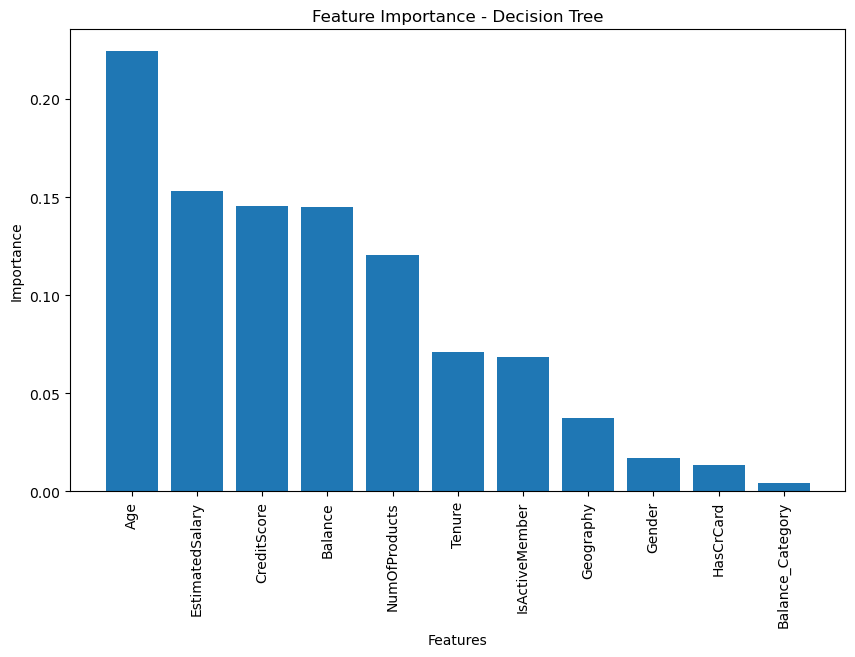

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
df = pd.read_csv(r"C:\Users\amrit\Downloads\archive (1)\Churn_Modelling.csv")
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])
df["Balance_Category"] = df["Balance"].apply(
    lambda x: "Low" if x < 50000
    else "Medium" if x < 150000
    else "High"
)
label_encoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])
X = df.drop(
    ["Exited", "Surname", "CustomerId", "RowNumber"],
    axis=1
)
y = df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model = DecisionTreeClassifier(
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print("\nFeature Importance:\n")
print(feature_importance)
plt.figure(figsize=(10, 6))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Decision Tree")

plt.show()